In [1]:
# open pickle files of numpy data and plot examples. The numpy data is in 3D arrays of shape (timestep, x, y) where the value is the exposure rate as determined by delfic
import numpy as np
import matplotlib.pyplot as plt
import pickle

sourceDirectory = './delfic_test/'

#build a list of all the folders in the source directory
import os
folders = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

#the folder name contains the metadata for the data, the format is dynamic based off the following code
# self.run_name = f"Y{int(self.blast_yield)}H{int(self.burst_height)}"
# self.run_name += f"SS{int(self.surface_wind_speed)}DS{int(self.surface_wind_direction)}"
# self.run_name += f"SA{int(self.winds_aloft_max)}BA{int(self.boundary_alt)}"
# the run_name becomes the folder name

folder: Y100H0SS5DS200SA16BA6944 310
(24, 512, 512)


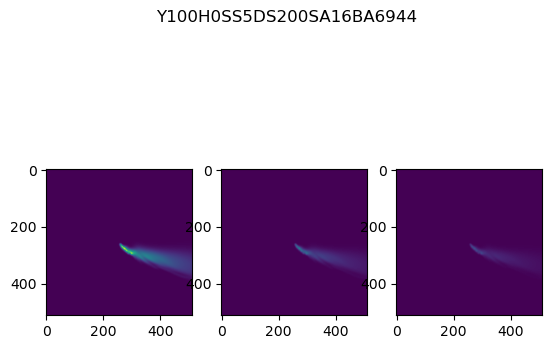

In [28]:
#use a random folder to open the pickle file and get the metadata
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}", idx)
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)
    print(data.shape)

#plot the data for the first three timesteps
# use the same scale on the colorbar for all plots
#find the max and min of the data
maxVal = np.max(data)
minVal = np.min(data)
plt.figure()
plt.subplot(131)
plt.imshow(data[0], vmin=minVal, vmax=maxVal)
plt.subplot(132)
plt.imshow(data[1], vmin=minVal, vmax=maxVal)
plt.subplot(133)
plt.imshow(data[2], vmin=minVal, vmax=maxVal)
#provide a super label using the folder name
plt.suptitle(folder)
plt.show()

folder: Y30H0SS6DS95SA21BA5403 1080
(24, 512, 512)
Wind Direction: 95
dir: 185
distance: 100


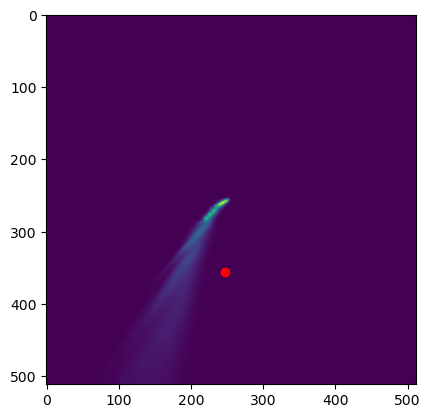

In [65]:
idx = 310
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}", idx)
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)
    print(data.shape)

#get the wind direction from the folder name
# find the idx of the 'DS' in the folder name
DS_start = folder.find('DS') + 2
DS_end   = folder.find('SA')
DS = int(folder[DS_start:DS_end])
print(f"Wind Direction: {DS}")

#choose a random distance between 10 and 200
distance = np.random.randint(10, 200) #this is the distance from the blast to deploy the sensor field perpendicularly to the wind direction
distance = 100

#find the direction for the sensor field, perpendicular to the wind direction
if DS < 180:
    direction = DS + 90
else:
    direction = DS - 90



print('dir:', direction)
print('distance:', distance)    

#plot the first timestep of the data
plt.figure()
plt.imshow(data[0], vmin=np.min(data[0]), vmax=np.max(data[0]))
#draw a red dot at the center of the detector field
# it is distance away from the center of the blast in the direction of the wind
# the blast is at the center of the image
# the image is 512x512 pixels
plt.plot(256+distance*np.cos(np.radians(direction-90)), 256+distance*np.sin(np.radians(direction-90)), 'ro')
plt.show()